# California House Price Prediction using Machine Learning

## Objective
The objective of this project is to predict California housing prices using Machine Learning regression models.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Models Used
- Linear Regression
- Polynomial Regression

## Dataset
California Housing Dataset from Kaggle

First 5 rows of dataset:

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset Information:

<class 'pandas.core.frame.

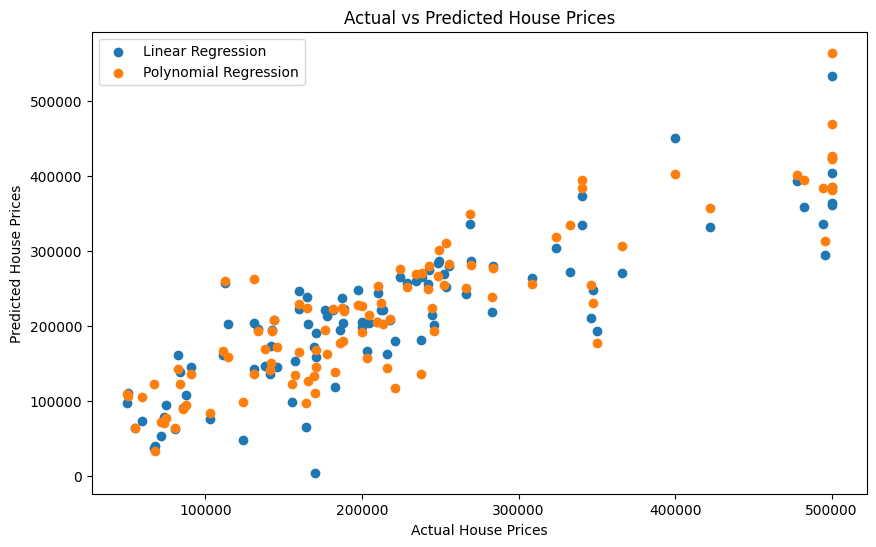


Final Comparison:

Polynomial Regression gives better prediction accuracy.


In [2]:
# California House Price Prediction Project

# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error


# loading the dataset

housing_data = pd.read_csv("housing.csv")

print("First 5 rows of dataset:\n")
print(housing_data.head())

# checking dataset information

print("\nDataset Information:\n")
print(housing_data.info())

# checking missing values

print("\nMissing Values:\n")
print(housing_data.isnull().sum())


# removing null values
housing_data = housing_data.dropna()

# converting categorical column

housing_data = pd.get_dummies(
    housing_data,
    columns=["ocean_proximity"],
    drop_first=True
)

# separating input and output data

x = housing_data.drop("median_house_value", axis=1)

y = housing_data["median_house_value"]

# splitting dataset into training and testing data

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

linear_prediction = linear_model.predict(x_test)


# calculating performance
linear_r2 = r2_score(y_test, linear_prediction)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_prediction)
)

print("\n------ Linear Regression Result ------")

print("R2 Score :", linear_r2)

print("RMSE :", linear_rmse)

# Polynomial Regression Model

poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)

x_test_poly = poly.transform(x_test)


poly_model = LinearRegression()

poly_model.fit(x_train_poly, y_train)

poly_prediction = poly_model.predict(x_test_poly)


# calculating performance
poly_r2 = r2_score(y_test, poly_prediction)

poly_rmse = np.sqrt(
    mean_squared_error(y_test, poly_prediction)
)

print("\n------ Polynomial Regression Result ------")

print("R2 Score :", poly_r2)

print("RMSE :", poly_rmse)

# plotting graph

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test[:100],
    linear_prediction[:100],
    label="Linear Regression"
)

plt.scatter(
    y_test[:100],
    poly_prediction[:100],
    label="Polynomial Regression"
)

plt.xlabel("Actual House Prices")

plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.legend()

plt.show()

# final comparison

print("\nFinal Comparison:\n")

if poly_r2 > linear_r2:
    print("Polynomial Regression gives better prediction accuracy.")

else:
    print("Linear Regression gives better prediction accuracy.")